Here in week four the topic is divide-and-conquer which is an algorithmic paradigme that finds a solution to a problem by

1. Splitting the problem into two or more subproblems
2. Solve each subproblem in isolation and if it's small enough solve it directly
3. Merge the solutions of the subproblems to get the solutions to the original problem

The merge sort algorithm and the binary search are good examples of divide and conquer algorithms, because they split the array needed to be sorted or searched in two such that we quickly reduce the size of the problem.

Quick thought about football. A team is made up of individuals and each individual skill may be merged into a cohesive whole. We can tackle each player skill as a subproblem working on the individual qualities to improve the whole. This means guiding them on how to build up play, how to look up, how to pass and when to pass and when to dribble. 

## 4.2.4 Speeding-up randomized quick sort

quick sort is one of those algorithms that also uses a divide and conquer approach. Below here is a visual sketch of how it works by having a pivot which every element is compared against. We want to choose a pivot that is balanced meaning that it's not the maximum or minimum value in the array.

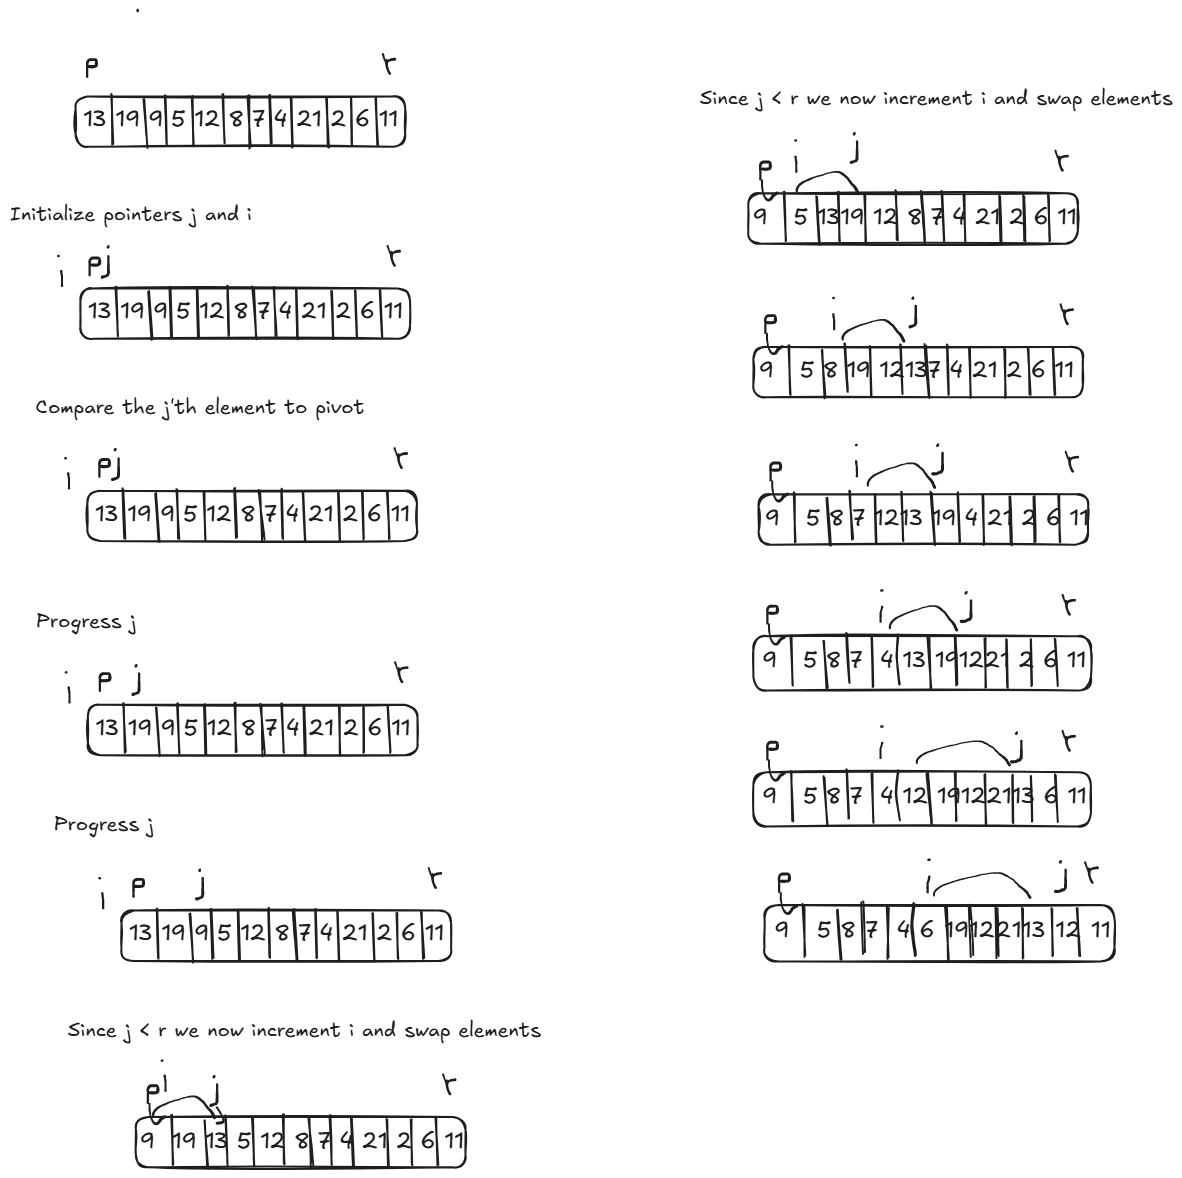

The algorithm it self uses pointers, one that is the current index in the beginning of the array, for those items lower than the pivot

Sort a given sequence of numbers (that may contain duplicates) using a modification of RandomizedQuickSort that works in $O(n log n)$ expected time.
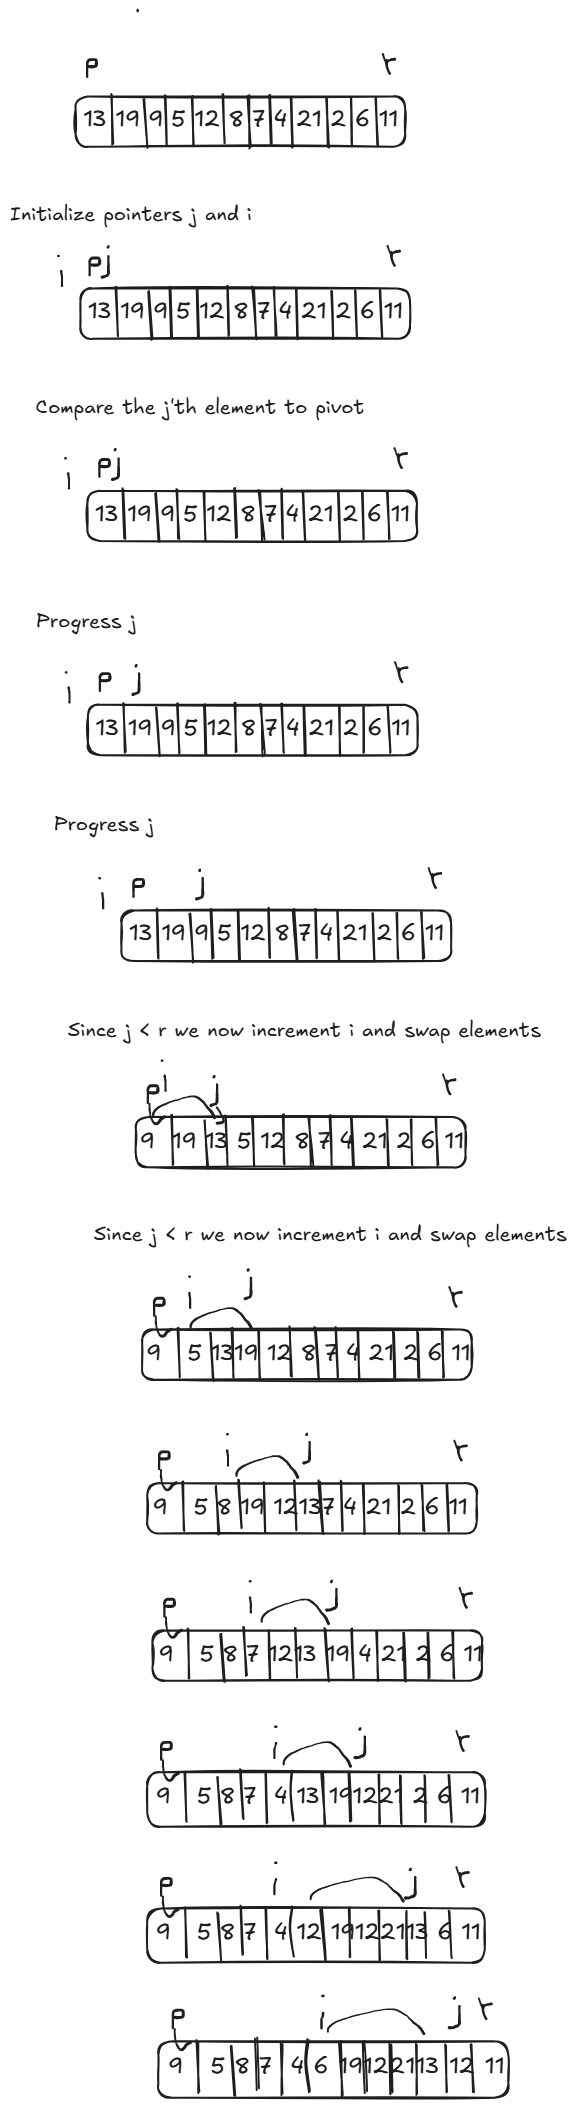

In [12]:
from cmath import inf


def quick_sort(array, low=0, high=None):
    if high is None:
        high = len(array) - 1
    if low < high:
        pivot_index = partition(array, low, high)
        quick_sort(array, low, pivot_index-1)
        quick_sort(array, pivot_index+1, high)
    return array

In [13]:
def partition(array, low, high):
    pivot = array[high] # setting the current pivot to the last element in the input array
    current_index_in_low_array = low-1 # defining the pointer for the current index in the
                                     # low part of the array

    for index in range(low, high): # looping through elements from low to high
        if array[index] <= pivot:  # if element at index is less than pivot, increment and put at
                                   # start of the array
            current_index_in_low_array += 1
            array[current_index_in_low_array], array[index] = array[index], array[current_index_in_low_array]

    array[current_index_in_low_array+1], array[high] = array[high], array[current_index_in_low_array+1]

    return current_index_in_low_array + 1

## 4.2.5 Number of inversions

Compute the number of inversions in a sequence
of integers.
Input: A sequence of n integers
a1,...,an.
Output: The number of inver
sions in the sequence, i.e., the
number of indices i <j such that
ai > aj. The naive algorithm which is shown below compares each element starting at the first one, against every other element and if it is greater increments the number of inversions. Then we progress and the next element compares against $n-1$ elements. In total this means we check all possible pairs leading to a running time of $O(n^2)$. 

In [41]:
def number_of_inversions(integers):
    num_inversions = 0
    for i in range(0, len(integers)):
        print(f'Checking the number at index {i} which is currently {integers[i]}')
        for j in range(i+1, len(integers)):
            print(f'Comparing it to the number at index {j} to see if it is greater than')
            print(f'If {integers[i]} is greater than {integers[j]} we have an inversion')
            if integers[i] > integers[j]:
                num_inversions += 1

    return num_inversions

In [42]:
number_of_inversions([9,7,6,3])

Checking the number at index 0 which is currently 9
Comparing it to the number at index 1 to see if it is greater than
If 9 is greater than 7 we have an inversion
Comparing it to the number at index 2 to see if it is greater than
If 9 is greater than 6 we have an inversion
Comparing it to the number at index 3 to see if it is greater than
If 9 is greater than 3 we have an inversion
Checking the number at index 1 which is currently 7
Comparing it to the number at index 2 to see if it is greater than
If 7 is greater than 6 we have an inversion
Comparing it to the number at index 3 to see if it is greater than
If 7 is greater than 3 we have an inversion
Checking the number at index 2 which is currently 6
Comparing it to the number at index 3 to see if it is greater than
If 6 is greater than 3 we have an inversion
Checking the number at index 3 which is currently 3


6

Instead we can use divide and conquer which allows us to accomplish the same result in $O(n \space log \space n)$ time. If we split the input array into halves and sort at the same time we can improve the running time drastically. So the following algorithm

1. Splits the input array of integers into halfs recursively until only one element remains.
2. calls merge_and_count on the first half and second half
3. the merge and count part makes initialize results, inversions and index i,j
4. Then it compares the element in the first half and second half and appends the lowest to result.
5. if the left element is greater than the right element then we have an inversion and we increment the counter by the whole length of the left since the left part will already be sorted, which means all the elements in the left part is greater than the right element. 

In [103]:
def number_of_inversions_optimized(integers):
    if len(integers) == 1: # base case return statement to come out of recursive call
        return integers, 0
    mid = len(integers)//2
    # recursively half the array into two smaller subproblems
    first_half, left_inv = number_of_inversions_optimized(integers[:mid])
    second_half, right_inv = number_of_inversions_optimized(integers[mid:])

    merged, split_inv = merge_and_count(first_half, second_half)

    return merged, left_inv + right_inv + split_inv

def merge_and_count(left,right):
    result = []
    inversions = 0
    i = j = 0
    # sort the array by comparison
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            inversions += len(left) - i
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result, inversions



In [106]:
number_of_inversions_optimized([9,7,6,3])

([3, 6, 7, 9], 6)

## 4.2.6 Organizing a lottery

You are organizing an online lottery. To participate, a person bets on
a single integer. You then draw several segments of consecutive integers at
random. A participant’s payoff is proportional to the number of segments
that contain the participant’s number. You need an efficient algorithm for
computing the payoffs for all participants. A simple scan of the list of all
ranges for each participant is too slow since your lottery is very popular:
you have thousands of participants and thousands of ranges.

**Points and Segments Problem**

Given a set of points and a set of segments on a line, compute, for each point, the number of
segments it is contained in.

**Input**: A list of segments and a list of points.

**Output**: The number of segments containing each point.

Sample input here with two segments and three points. The first point lies only in the first segment while the remaining two points are outside of all segments.

* 2 3
* 0 5
* 7 10
* 1 6 11

Therefore we return 1 0 0

The naive algorithm loops through all points and checks how many segment pairs it lies between. This is an algorith that runs in $O(P x S)$ time so if there is 10 points and 10 segments it needs to make 100 checks.

In [121]:
def organizating_a_lottery(segments, points):
    output = [0]*len(points) # setting up the output array

    for point in range(0, len(points)):
        for segment in segments:
            if points[point] >= segment[0] and points[point] <= segment[1]:
                output[point] += 1
    return output


In [123]:
organizating_a_lottery([[0,5], [7,10]], [1,6,11])

[1, 0, 0]

## 4.2.7 Closest Points

This computational geometry problem has many applications in computer graphics and vision. A naive algorithm with quadratic running time iterates through all pairs of points to find the closest pair. Your goal is to design an $O(nlogn)$ time divide and conquer algorithm.
To solve this problem in time $O(nlogn)$, let’s first split the given n points
by an appropriately chosen vertical line into two halves S1 and S2 of size n
2 (assume for simplicity that all x-coordinates of the input points are different). By making two recursive calls for the sets S1 and S2, we find the minimum distances d1 and d2 in these subsets. Let d =min{d1,d2}.

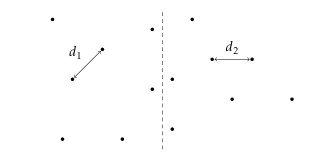

It remains to check whether there exist points p1 ∈ S1 and p2 ∈ S2 such that
the distance between them is smaller than d. We cannot afford to check
all possible such pairs since there are n
2 · n
2 = Θ(n2) of them. To check this
faster, we first discard all points from S1 and S2 whose x-distance to the
middle line is greater than d. That is, we focus on the following strip:

In [1]:
import math

In [5]:
def closests_points(points):

    sorted_points = sorted(points)
    mid = len(sorted_points)//2
    first_half = sorted_points[:mid]
    second_half = sorted_points[mid:]
    def minimum_distance(points):
        i = 0
        j = 1
        min_distance = float('inf')
        while i <= len(points)-1:
            while j <= len(points)-1:
                print(f' calculating distance between {(points[i], points[j])}')
                distance = math.sqrt((points[i][0]-points[j][0])**2+(points[i][1]-points[j][1])**2)
                if distance < min_distance:
                    min_distance = distance
                j += 1
            i += 1
            j = i+1


        return min_distance

    min_first_half = minimum_distance(first_half)
    min_second_half = minimum_distance(second_half)

    min_d = min(min_first_half, min_second_half)
    print(mid)
    overlap_points = [point for point in sorted_points if abs(point[0])-points[mid][0] < min_d]


    return min_d, overlap_points

In [2]:
def closests_points(points):
    i = 0
    j = 1
    min_distance = float('inf')
    while i <= len(points)-1:
        while j <= len(points)-1:
            print(f' calculating distance between {(points[i], points[j])}')
            distance = math.sqrt((points[i][0]-points[j][0])**2+(points[i][1]-points[j][1])**2)
            if distance < min_distance:
                min_distance = distance
            j += 1
        i += 1
        j = i+1

    return min_distance


In [3]:
points = [(4,4), (-2,-2), (-3,-4), (-1,3), (2,3), (-4,0), (1,1),(-1,-1), (3,-1), (-4,2), (-2,4)]

In [4]:
closests_points(points)

 calculating distance between ((4, 4), (-2, -2))
 calculating distance between ((4, 4), (-3, -4))
 calculating distance between ((4, 4), (-1, 3))
 calculating distance between ((4, 4), (2, 3))
 calculating distance between ((4, 4), (-4, 0))
 calculating distance between ((4, 4), (1, 1))
 calculating distance between ((4, 4), (-1, -1))
 calculating distance between ((4, 4), (3, -1))
 calculating distance between ((4, 4), (-4, 2))
 calculating distance between ((4, 4), (-2, 4))
 calculating distance between ((-2, -2), (-3, -4))
 calculating distance between ((-2, -2), (-1, 3))
 calculating distance between ((-2, -2), (2, 3))
 calculating distance between ((-2, -2), (-4, 0))
 calculating distance between ((-2, -2), (1, 1))
 calculating distance between ((-2, -2), (-1, -1))
 calculating distance between ((-2, -2), (3, -1))
 calculating distance between ((-2, -2), (-4, 2))
 calculating distance between ((-2, -2), (-2, 4))
 calculating distance between ((-3, -4), (-1, 3))
 calculating distan

1.4142135623730951